# Kelly allocation: growth, exposure and uncertain probabilities

The Kelly optimum is conditional on the outcome distribution. A known binary example checks the mathematics; an explicit scenario portfolio then shows how cash and admissible wealth enter the allocation problem. All probabilities and returns are constructed.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy.optimize import minimize
from IPython.display import display
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'research/allocation.py').is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
plt.rcParams.update({'figure.figsize': (9, 4.8), 'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.18})

## Expected log growth per opportunity

A 55% win probability at even odds gives the exact interior fraction 10%. Growth here is per round in log units; it is not an annualized market return.

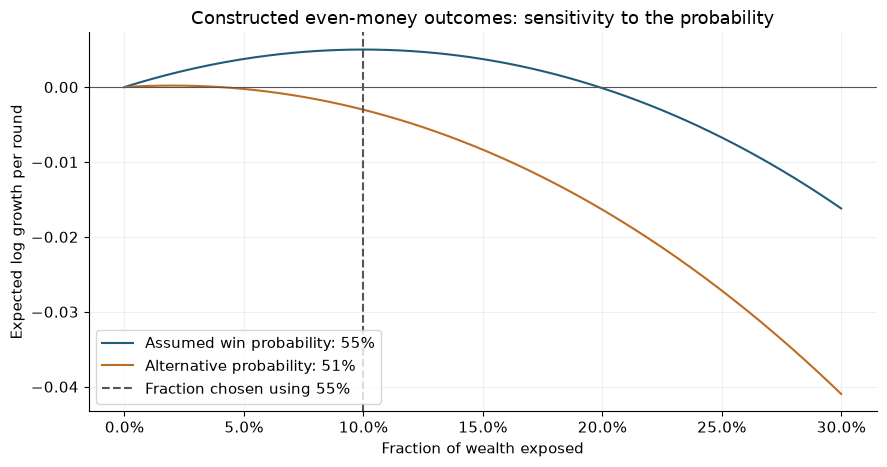

,Exposure,Fraction,Log growth at 55%,Log growth at 51%
0,Full fraction,0.10,0.005008,-0.003018
1,Half fraction,0.05,0.003753,-0.000251
2,Cash,0.00,0.000000,0.000000


In [2]:
from scipy.optimize import minimize_scalar

def growth(f, probability):
    return probability*np.log1p(f)+(1-probability)*np.log1p(-f)

p_assumed, p_alternative = 0.55, 0.51
fraction = 2*p_assumed-1
solution = minimize_scalar(lambda f: -growth(f, p_assumed), bounds=(0, .99), method='bounded', options={'xatol':1e-12})
assert solution.success
np.testing.assert_allclose(solution.x, fraction, atol=1e-7)
grid = np.linspace(0, .3, 301)
fig, ax = plt.subplots()
ax.plot(grid, growth(grid,p_assumed), label='Assumed win probability: 55%', color='#205b78')
ax.plot(grid, growth(grid,p_alternative), label='Alternative probability: 51%', color='#bc6c25')
ax.axvline(fraction, color='#555', ls='--', label='Fraction chosen using 55%')
ax.axhline(0,color='#555',lw=.8)
ax.set(xlabel='Fraction of wealth exposed', ylabel='Expected log growth per round', title='Constructed even-money outcomes: sensitivity to the probability')
ax.xaxis.set_major_formatter(PercentFormatter(1)); ax.legend(); fig.tight_layout(); plt.show()
comparison = pd.DataFrame([{'Exposure': name, 'Fraction': f, 'Log growth at 55%': growth(f,p_assumed), 'Log growth at 51%': growth(f,p_alternative)} for name,f in [('Full fraction',fraction),('Half fraction',fraction/2),('Cash',0)]])
display(comparison.round(6))
assert growth(fraction,p_alternative)<0

## An explicit scenario portfolio

Five one-period outcomes describe two illustrative risky assets. Residual cash returns zero. Maximize the probability-weighted logarithm of gross wealth, using simple returns and an explicit budget.

In [3]:
probabilities = np.array([.20,.25,.25,.10,.20])
returns = np.array([[.15,.04],[.06,.02],[-.12,.015],[-.25,-.02],[.30,.03]])
assert np.isclose(probabilities.sum(),1)

def negative_log_growth(w):
    wealth = 1+returns @ w
    if (wealth<=0).any():
        return np.inf
    return -probabilities @ np.log(wealth)

result = minimize(negative_log_growth,[.3,.3],method='SLSQP',bounds=[(0,1)]*2,
                  constraints=[{'type':'ineq','fun':lambda w:1-w.sum()}],options={'ftol':1e-13,'maxiter':1000})
assert result.success,result.message
w = result.x
assert w.min()>=-1e-9 and w.sum()<=1+1e-9
assert (1+returns @ w>0).all()
display(pd.DataFrame({'Probability':probabilities,'Asset A return':returns[:,0],'Asset B return':returns[:,1],'Portfolio gross wealth':1+returns @ w}).round(6))
display(pd.Series([*w,max(0,1-w.sum())],index=['Asset A','Asset B','Cash'],name='Scenario-optimal weight').round(6))
assert negative_log_growth(w)<=negative_log_growth(np.zeros(2))+1e-10
print('Binary closed form, admissible wealth, probability and budget checks: passed.')

,Probability,Asset A return,Asset B return,Portfolio gross wealth
0,0.20,0.15,0.040,1.15
1,0.25,0.06,0.020,1.06
2,0.25,-0.12,0.015,0.88
3,0.10,-0.25,-0.020,0.75
4,0.20,0.30,0.030,1.30


Asset A    1.0
Asset B    0.0
Cash       0.0
Name: Scenario-optimal weight, dtype: float64

Binary closed form, admissible wealth, probability and budget checks: passed.


## Interpretation

The optimum is exact for the constructed distribution and constraints. It is not evidence that these probabilities describe markets. Missing adverse outcomes and a small error in an estimated edge can matter more than numerical precision. [Research note and original reference](README.md).